# Capstone Project: Bellabeat

# 1. Introduction

This project aims to analyze fitness and wellness data from
non-Bellabeat smart devices to uncover trends in smart device usage. By
identifying patterns in user behavior, the analysis will inform
marketing strategies for Bellabeat app product, focusing on enhancing
customer engagement and promoting healthy habits.

# 2. Data Sources

The dataset used in this analysis is the [FitBit Fitness Tracker
Data](https://www.kaggle.com/datasets/arashnic/fitbit) provided through
[Mobius](https://www.kaggle.com/arashnic). This dataset generated by
respondents to a distributed survey via Amazon Mechanical Turk between
03.12.2016-05.12.2016.Thirty eligible Fitbit users consented to the
submission of personal tracker data, including minute-level output for
physical activity, heart rate, and sleep monitoring. It includes
information about daily activity, steps, and heart rate that can be used
to explore users’ habits. The dataset provides comprehensive details on
daily activity, calorie burn, and sleep patterns, aligning closely with
the features of the Leaf wellness tracker. By leveraging this data, we
can uncover trends in device usage that can inform Bellabeat's product
positioning and marketing strategy.

# 3. Data Loading and Exploration

## Setting up R environment

Notes: Install required packages if not already installed


Loading required packages


In [1]:

library(tidyverse)
library(lubridate)
library(skimr)
library(janitor)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




## Load datasets

Loaded data from "Fitabase Data 4.12.16-5.12.1"

In [2]:
daily_activity <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")

sleep_data <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")

intensity_data <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyIntensities_merged.csv")

Viewed the structure and summary of the datasets


In [3]:
glimpse(daily_activity)
glimpse(intensity_data)
glimpse(sleep_data)

Rows: 940
Columns: 15
$ Id                       <dbl> 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityDate             <chr> "4/12/2016", "4/13/2016", "4/14/2016", "4/15/…
$ TotalSteps               <int> 13162, 10735, 10460, 9762, 12669, 9705, 13019…
$ TotalDistance            <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ TrackerDistance          <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ LoggedActivitiesDistance <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveDistance       <dbl> 1.88, 1.57, 2.44, 2.14, 2.71, 3.19, 3.25, 3.5…
$ ModeratelyActiveDistance <dbl> 0.55, 0.69, 0.40, 1.26, 0.41, 0.78, 0.64, 1.3…
$ LightActiveDistance      <dbl> 6.06, 4.71, 3.91, 2.83, 5.04, 2.51, 4.71, 5.0…
$ SedentaryActiveDistance  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveMinutes        <int> 25, 21, 30, 29, 36, 38, 42, 50, 28, 19, 66, 4…
$ FairlyActiveMinutes      <int> 13, 19, 11, 34, 10, 20, 16, 31, 12, 8, 27, 21…
$ LightlyActiveMin

Rows: 22,099
Columns: 4
$ Id               <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 15039…
$ ActivityHour     <chr> "4/12/2016 12:00:00 AM", "4/12/2016 1:00:00 AM", "4/1…
$ TotalIntensity   <int> 20, 8, 7, 0, 0, 0, 0, 0, 13, 30, 29, 12, 11, 6, 36, 5…
$ AverageIntensity <dbl> 0.333333, 0.133333, 0.116667, 0.000000, 0.000000, 0.0…


Rows: 413
Columns: 5
$ Id                 <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 150…
$ SleepDay           <chr> "4/12/2016 12:00:00 AM", "4/13/2016 12:00:00 AM", "…
$ TotalSleepRecords  <int> 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ TotalMinutesAsleep <int> 327, 384, 412, 340, 700, 304, 360, 325, 361, 430, 2…
$ TotalTimeInBed     <int> 346, 407, 442, 367, 712, 320, 377, 364, 384, 449, 3…


# 4. Data Cleaning and Manipulation

First, checked for missing values in the datasets.

In [4]:
sum(is.na(daily_activity))
sum(is.na(sleep_data))
sum(is.na(intensity_data))

[1] 0

[1] 0

[1] 0

Notes: From the output, there was no missing value in the datasets.

Then, checked for duplicated data

In [5]:
# Checking for duplicate Data
sum(duplicated(daily_activity))
sum(duplicated(sleep_data))
sum(duplicated(intensity_data))

[1] 0

[1] 3

[1] 0

Notes: From the output, the "sleep_data" table had 3 duplicated data.
Removing duplicate data ensure accurate analysis of sleep patterns


In [6]:
# Removed duplicated data in sleep_data
sleep_data_clean <- distinct(sleep_data)

In [7]:
# Checking for unrealistic values in daily_activity
unrealistic_values <- daily_activity %>%
  filter(TotalSteps<=0 & TotalDistance<= 0 & Calories<=0)
print(unrealistic_values)

          Id ActivityDate TotalSteps TotalDistance TrackerDistance
1 1503960366    5/12/2016          0             0               0
2 6290855005    5/10/2016          0             0               0
3 8253242879    4/30/2016          0             0               0
4 8583815059    5/12/2016          0             0               0
  LoggedActivitiesDistance VeryActiveDistance ModeratelyActiveDistance
1                        0                  0                        0
2                        0                  0                        0
3                        0                  0                        0
4                        0                  0                        0
  LightActiveDistance SedentaryActiveDistance VeryActiveMinutes
1                   0                       0                 0
2                   0                       0                 0
3                   0                       0                 0
4                   0                       0         

In [8]:
daily_activity_clean <- daily_activity %>%
  filter(!(TotalSteps<=0 & TotalDistance<= 0 & Calories<=0))

Notes: Four rows had Calories equal to 0. These rows were excluded as
they represent missing or invalid data.

In [9]:
# Renamed all columns to lowercase for datasets
sleep_data_clean <- sleep_data_clean %>%
  rename_with(tolower)

daily_activity_clean <- daily_activity_clean %>%
  rename_with(tolower)

intensity_data_clean <- intensity_data %>%
  rename_with(tolower)

After viewing the data structures, I noticed the columns with dates and
time were not formatted appropriately.

In [10]:
# Formatted dates appropriately for the datasets

# daily activity
daily_activity_clean$activitydate=as.POSIXct(daily_activity_clean$activitydate, format="%m/%d/%Y", tz=Sys.timezone())

# sleep
sleep_data_clean$sleepday=as.POSIXct(sleep_data_clean$sleepday, format="%m/%d/%Y %I:%M:%S %p", tz=Sys.timezone())

# intensity
intensity_data_clean$activityhour=as.POSIXct(intensity_data_clean$activityhour, format="%m/%d/%Y %I:%M:%S %p", tz=Sys.timezone())
intensity_data_clean$time <- format(intensity_data_clean$activityhour, format = "%H:%M:%S")
intensity_data_clean$date <- format(intensity_data_clean$activityhour, format = "%m/%d/%y")

In [11]:
#Viewing the data with head() function
head(intensity_data_clean)
head(sleep_data_clean)
head(daily_activity_clean)

,id,activityhour,totalintensity,averageintensity,time,date
,<dbl>,<dttm>,<int>,<dbl>,<chr>,<chr>
1,1503960366,2016-04-12 00:00:00,20,0.333333,00:00:00,04/12/16
2,1503960366,2016-04-12 01:00:00,8,0.133333,01:00:00,04/12/16
3,1503960366,2016-04-12 02:00:00,7,0.116667,02:00:00,04/12/16
4,1503960366,2016-04-12 03:00:00,0,0.000000,03:00:00,04/12/16
5,1503960366,2016-04-12 04:00:00,0,0.000000,04:00:00,04/12/16
6,1503960366,2016-04-12 05:00:00,0,0.000000,05:00:00,04/12/16


,id,sleepday,totalsleeprecords,totalminutesasleep,totaltimeinbed
,<dbl>,<dttm>,<int>,<int>,<int>
1,1503960366,2016-04-12,1,327,346
2,1503960366,2016-04-13,2,384,407
3,1503960366,2016-04-15,1,412,442
4,1503960366,2016-04-16,2,340,367
5,1503960366,2016-04-17,1,700,712
6,1503960366,2016-04-19,1,304,320


,id,activitydate,totalsteps,totaldistance,trackerdistance,loggedactivitiesdistance,veryactivedistance,moderatelyactivedistance,lightactivedistance,sedentaryactivedistance,veryactiveminutes,fairlyactiveminutes,lightlyactiveminutes,sedentaryminutes,calories
,<dbl>,<dttm>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,2016-04-12,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,2016-04-13,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,2016-04-14,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,2016-04-15,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,2016-04-16,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,2016-04-17,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


In [12]:
# Cross-checking missing Values
sum(is.na(daily_activity_clean))
sum(is.na(sleep_data_clean))
sum(is.na(intensity_data_clean))

[1] 0

[1] 0

[1] 0

From this output, I confirmed that there was no missing value in the
datasets.

In [13]:
# 'date' columns in  daily_activity_clean and sleep_data_clean are renamed 'date' for merge
sleep_data_clean <- sleep_data_clean %>%
  rename(date = sleepday)

daily_activity_clean <- daily_activity_clean %>%
  rename(date = activitydate)

## 4.1 Exploring and Summarizing data

In [14]:
# Number of distinct participants in each dataset
n_distinct(daily_activity_clean$id)
n_distinct(sleep_data_clean$id)
n_distinct(intensity_data_clean$id)

[1] 33

[1] 24

[1] 33

The information above refers to the number of participants in each
dataset. The cleaned activity and intensity data has 33 participants
whilst the cleaned sleep data has 24 participants.

In [15]:
#Checked the number of rows/observations in each dataset
nrow(sleep_data_clean)
nrow(daily_activity_clean)
nrow(intensity_data_clean)

[1] 410

[1] 936

[1] 22099

The clean sleep data has 410 observations, daily activity data has 936
observations and intensity data has 22099 observations.

In [16]:
# daily activity
daily_activity_clean %>%  
  select(totalsteps,
         totaldistance,
         sedentaryminutes, calories) %>%
  summary()

# explore number of active minutes per category
daily_activity_clean %>%
  select(veryactiveminutes, fairlyactiveminutes, lightlyactiveminutes) %>%
  summary()

# sleep
sleep_data_clean %>%
  select(totalsleeprecords, totalminutesasleep, totaltimeinbed) %>%
  summary()

#intensity
 intensity_data_clean %>%
   select(totalintensity, averageintensity)%>%
   summary()

   totalsteps    totaldistance    sedentaryminutes    calories   
 Min.   :    0   Min.   : 0.000   Min.   :   0.0   Min.   :  52  
 1st Qu.: 3818   1st Qu.: 2.645   1st Qu.: 729.0   1st Qu.:1834  
 Median : 7441   Median : 5.265   Median :1057.0   Median :2144  
 Mean   : 7671   Mean   : 5.513   Mean   : 989.3   Mean   :2313  
 3rd Qu.:10734   3rd Qu.: 7.720   3rd Qu.:1226.0   3rd Qu.:2794  
 Max.   :36019   Max.   :28.030   Max.   :1440.0   Max.   :4900  

 veryactiveminutes fairlyactiveminutes lightlyactiveminutes
 Min.   :  0.00    Min.   :  0.00      Min.   :  0.0       
 1st Qu.:  0.00    1st Qu.:  0.00      1st Qu.:128.0       
 Median :  4.00    Median :  7.00      Median :199.0       
 Mean   : 21.26    Mean   : 13.62      Mean   :193.6       
 3rd Qu.: 32.00    3rd Qu.: 19.00      3rd Qu.:264.2       
 Max.   :210.00    Max.   :143.00      Max.   :518.0       

 totalsleeprecords totalminutesasleep totaltimeinbed 
 Min.   :1.00      Min.   : 58.0      Min.   : 61.0  
 1st Qu.:1.00      1st Qu.:361.0      1st Qu.:403.8  
 Median :1.00      Median :432.5      Median :463.0  
 Mean   :1.12      Mean   :419.2      Mean   :458.5  
 3rd Qu.:1.00      3rd Qu.:490.0      3rd Qu.:526.0  
 Max.   :3.00      Max.   :796.0      Max.   :961.0  

 totalintensity   averageintensity
 Min.   :  0.00   Min.   :0.0000  
 1st Qu.:  0.00   1st Qu.:0.0000  
 Median :  3.00   Median :0.0500  
 Mean   : 12.04   Mean   :0.2006  
 3rd Qu.: 16.00   3rd Qu.:0.2667  
 Max.   :180.00   Max.   :3.0000  

The summary statistics revealed interesting data points. Most notably
being the average total steps which is 7671 and the average calories
burned being 2313. [Centers for Disease Control and
Prevention](https://www.cdc.gov/pcd/issues/2016/16_0111.htm) recommends
walking at least 10,000 steps per day. The lightly active minutes
category recorded the highest mean out of the active minutes categories,
suggesting most participants are light active. Total Minutes asleep
recorded a mean of 419. This value is close to the recommended sleep
hours by the [American Academy of Sleep Medicine and Sleep Research
Society](https://pmc.ncbi.nlm.nih.gov/articles/PMC4434546/) which is 420
minutes.

## 4.2 Merging datasets

To analyze the relationship between activity levels and sleep patterns,
the daily_activity_clean and sleep_data_clean need to be merged. This
allows us to explore correlations and provide actionable insights.


In [17]:
# Merging the cleaned sleep_data and daily_activity by "id" and "date"
merged_data <- merge(sleep_data_clean, daily_activity_clean, by = c("id", "date"))
head(merged_data)

,id,date,totalsleeprecords,totalminutesasleep,totaltimeinbed,totalsteps,totaldistance,trackerdistance,loggedactivitiesdistance,veryactivedistance,moderatelyactivedistance,lightactivedistance,sedentaryactivedistance,veryactiveminutes,fairlyactiveminutes,lightlyactiveminutes,sedentaryminutes,calories
,<dbl>,<dttm>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,2016-04-12,1,327,346,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,2016-04-13,2,384,407,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,2016-04-15,1,412,442,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
4,1503960366,2016-04-16,2,340,367,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
5,1503960366,2016-04-17,1,700,712,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728
6,1503960366,2016-04-19,1,304,320,15506,9.88,9.88,0,3.53,1.32,5.03,0,50,31,264,775,2035


Merging ensures that activity and sleep data for each user are combined,
enabling a holistic analysis of user behavior trends.

In [18]:
# Number of distinct participants in merged data
n_distinct(merged_data$id)

[1] 24

There are 24 distinct participants in the merged data. This is because
the sleep data has 24 distinct participants and was merged with daily
activity data on id. For the merged data, I focused on participants that
were present in both datasets.

In [19]:
# Converted relevant columns from double to integer
merged_data$totalsleeprecords <- as.integer(merged_data$totalsleeprecords)
merged_data$totalsteps <- as.integer(merged_data$totalsteps)
merged_data$totalminutesasleep <- as.integer(merged_data$totalminutesasleep)
merged_data$totaltimeinbed <- as.integer(merged_data$totaltimeinbed)
merged_data$veryactiveminutes <- as.integer(merged_data$veryactiveminutes)
merged_data$fairlyactiveminutes <- as.integer(merged_data$fairlyactiveminutes)
merged_data$lightlyactiveminutes <- as.integer(merged_data$lightlyactiveminutes)
merged_data$sedentaryminutes <- as.integer(merged_data$sedentaryminutes)
merged_data$calories <- as.integer(merged_data$calories)


# 5. Exploratory Data Analysis (EDA)

In this section, I focused on the outlined questions below to draw
insights from the datasets:

* What are the activity trends (e.g., steps, active minutes) across
    users?

* Are there correlations between activity levels and sleep patterns?

* What percentage of users achieve recommended activity or sleep levels?

## 5.1 Activity Trends across Users

I analyzed trends like total steps, calories burned, and active minutes.

In [20]:
# Summarized activity trends
activity_summary <- daily_activity_clean %>%
  group_by(date) %>%
  summarise(
    avg_steps = mean(totalsteps, na.rm = TRUE),
    avg_calories = mean(calories, na.rm = TRUE),
    avg_active_minutes = mean(veryactiveminutes + fairlyactiveminutes + lightlyactiveminutes, na.rm = TRUE)
  )

print(activity_summary)

# A tibble: 31 × 4
   date                avg_steps avg_calories avg_active_minutes
   <dttm>                  <dbl>        <dbl>              <dbl>
 1 2016-04-12 00:00:00     8237.        2391.               229.
 2 2016-04-13 00:00:00     7199.        2287.               213.
 3 2016-04-14 00:00:00     7744.        2356.               234.
 4 2016-04-15 00:00:00     7534.        2355.               243.
 5 2016-04-16 00:00:00     8679.        2393.               237.
 6 2016-04-17 00:00:00     6409.        2231.               196.
 7 2016-04-18 00:00:00     7897.        2333.               229.
 8 2016-04-19 00:00:00     8049.        2359.               240.
 9 2016-04-20 00:00:00     8163.        2395.               247.
10 2016-04-21 00:00:00     8244.        2422.               224.
# ℹ 21 more rows


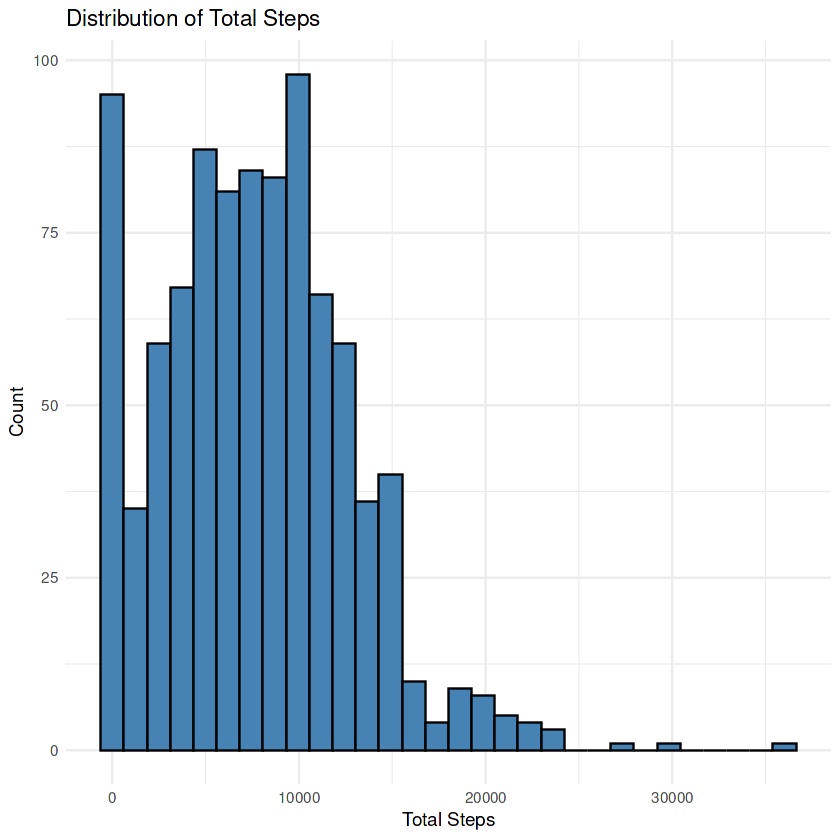

In [21]:
# Step distribution
ggplot(daily_activity_clean, aes(x = totalsteps)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 30) +
  labs(title = "Distribution of Total Steps", x = "Total Steps", y = "Count") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


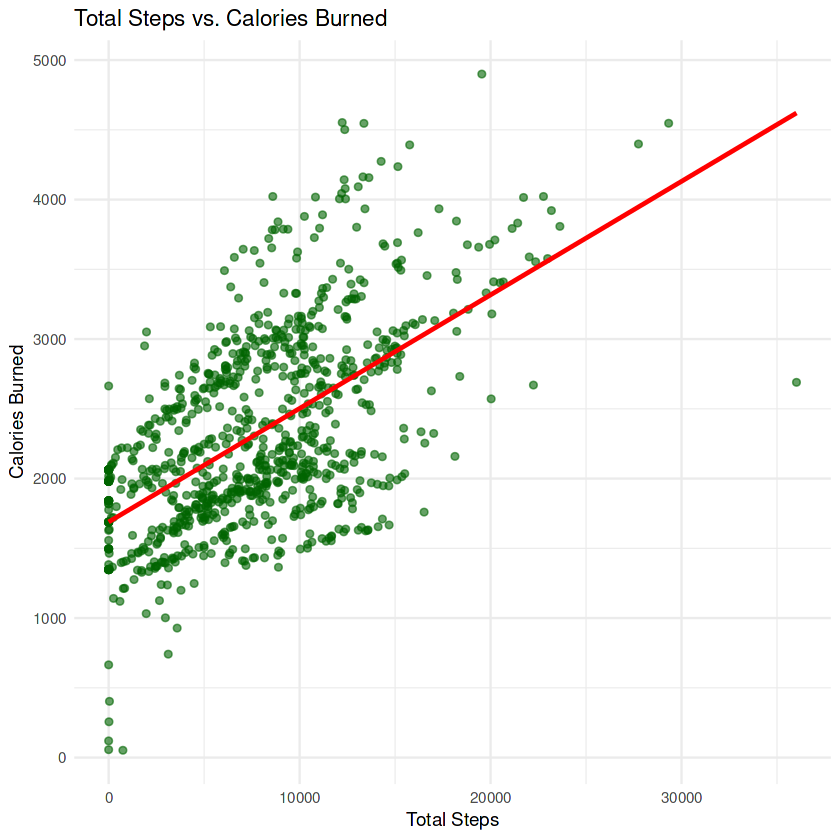

In [22]:
# Total Steps vs. Calories burned
ggplot(daily_activity_clean, aes(x = totalsteps, y = calories)) +
  geom_jitter(alpha = 0.6, color = "darkgreen") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(title = "Total Steps vs. Calories Burned" , x = "Total Steps", y = "Calories Burned") +
  theme_minimal()

**Observations**:

**Distribution of Total Steps:**

* The histogram shows a right-skewed distribution.

* There's a notable peak around 8,000-10,000 steps, suggesting this might be a common daily goal.

**Calories Burned vs. Total Steps:**

* The scatter plot suggests a positive linear correlation.

* Higher steps are generally associated with higher calorie burns.

In [23]:
# Assessing activity intensity over hourly time
# Summarizing by mean of total intensity, group by time
int_summary <- intensity_data_clean %>%
  group_by(time) %>%
  summarise(mean_total_int = mean(totalintensity))

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


`geom_smooth()` using formula = 'y ~ x'


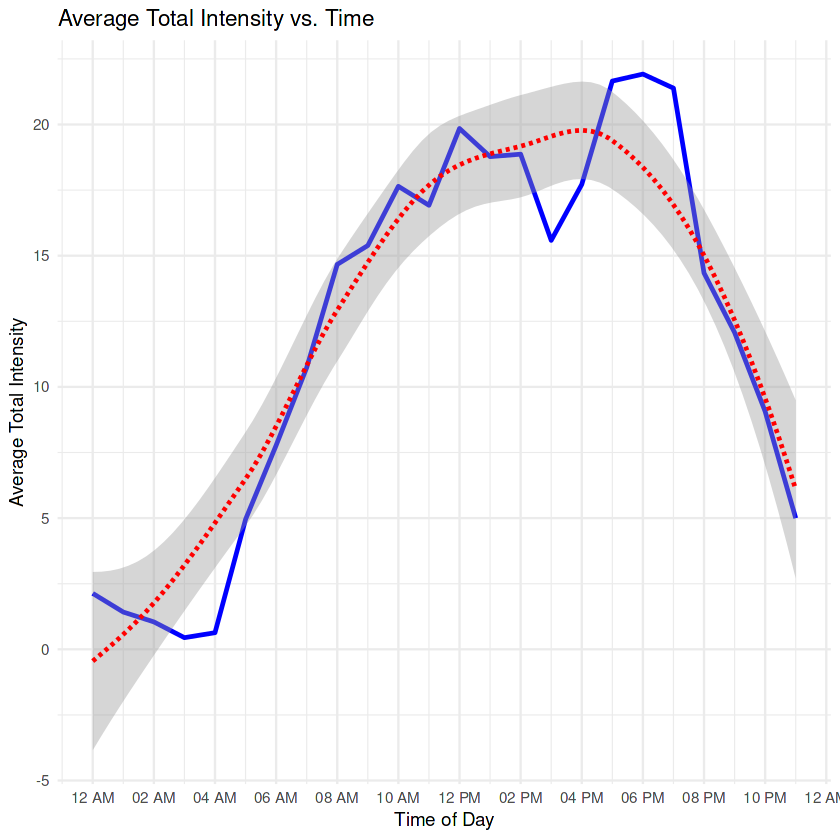

In [24]:
# Visualizing Average intensity vs. Time

# Convert time back to POSIXct for proper ordering in the chart
int_summary$time <- as.POSIXct(int_summary$time, format = "%H:%M")

# Plot line chart
ggplot(int_summary, aes(x = time, y = mean_total_int)) +
  geom_line(color = "blue", size = 1) +
  geom_smooth(method = "loess", color = "red", linetype = "dashed") + 
  labs(
    title = "Average Total Intensity vs. Time",
    x = "Time of Day",
    y = "Average Total Intensity"
  ) +
  scale_x_datetime(
    date_labels = "%I %p",  # Format x-axis as "6 AM," "12 PM"
    date_breaks = "2 hours"  # Break axis labels every 2 hours
  ) +
  theme_minimal()

**Observations:**

* Peak activity occurs between 17:00-19:00 (5-7 PM), reaching
    intensity levels around 20

* Gradual increase starting around 05:00 (5 AM)

* Steady decline in intensity after 19:00 (7 PM)

Notes: The pattern suggests typical daily routines with morning
activity, lunch hour movement, and highest activity during evening
hours.

`geom_smooth()` using formula = 'y ~ x'


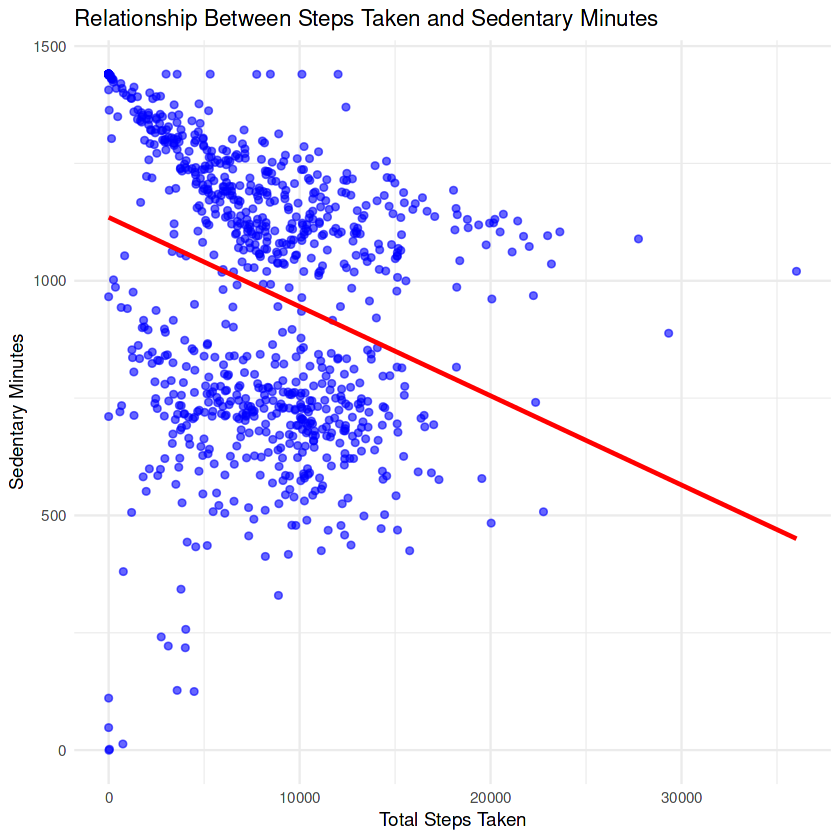

In [25]:
# Scatter Plot: Steps Taken vs. Sedentary Minutes
ggplot(daily_activity_clean, aes(x = totalsteps, y = sedentaryminutes)) +
  geom_jitter(alpha = 0.6, color = "blue") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(
    title = "Relationship Between Steps Taken and Sedentary Minutes",
    x = "Total Steps Taken",
    y = "Sedentary Minutes"
  ) +
  theme_minimal()

**Observations:**

* Clear negative correlation between steps taken and sedentary minutes

* High variability/scatter around the trend line, suggesting other factors influence sedentary time

* Some outliers with very low sedentary minutes (\<200) and very high steps (\>25,000)

* Trend line suggests roughly 600 minute decrease in sedentary time from 0 to 30,000 steps

Notes: The relationship appears meaningful but moderate, with
considerable individual variation.

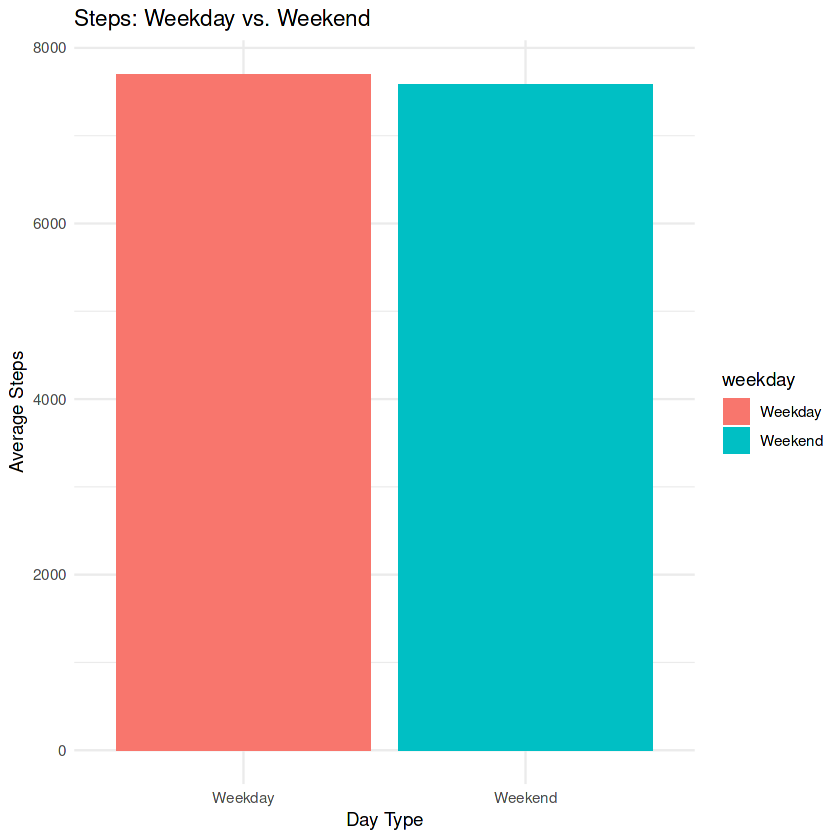

In [26]:
# Weekday vs. Weekend Analysis
daily_activity_clean <- daily_activity_clean %>%
  mutate(weekday = ifelse(weekdays(date) %in% c("Saturday", "Sunday"), "Weekend", "Weekday"))

activity_weekday <- daily_activity_clean %>%
  group_by(weekday) %>%
  summarise(
    avg_steps = mean(totalsteps),
    avg_calories = mean(calories)
  )

# Plot comparison
ggplot(activity_weekday, aes(x = weekday, y = avg_steps, fill = weekday)) +
  geom_bar(stat = "identity") +
  labs(title = "Steps: Weekday vs. Weekend", x = "Day Type", y = "Average Steps") +
  theme_minimal()

**Observation:** Weekday vs. weekend step counts are nearly identical, indicating consistent activity levels throughout the week. This suggests good maintenance of activity habits regardless of the day type.

## 5.2 Correlation between Activity and Sleep

I assessed the relationship between activity and sleep

`geom_smooth()` using formula = 'y ~ x'


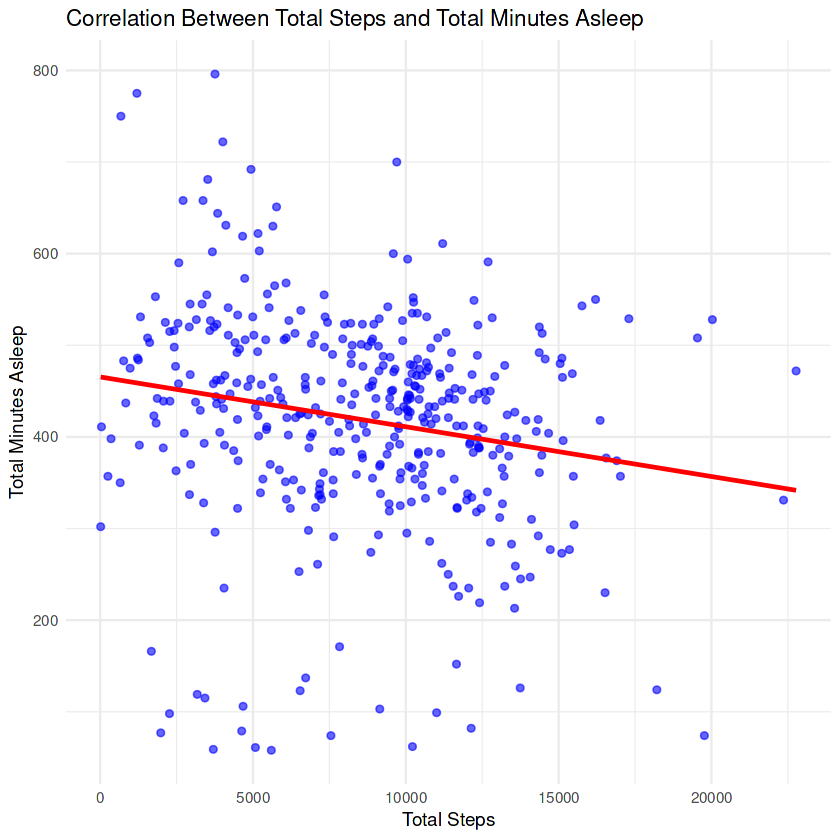

In [27]:
# Scatter plot: Total Steps vs. Total Minutes Asleep
ggplot(merged_data, aes(x = totalsteps, y = totalminutesasleep)) +
  geom_point(alpha = 0.6, color = "blue") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(
    title = "Correlation Between Total Steps and Total Minutes Asleep",
    x = "Total Steps",
    y = "Total Minutes Asleep"
  ) +
  theme_minimal()

**Observation:** There is a slight negative correlation between daily steps and sleep duration. As steps increase, minutes of sleep tends to decrease slightly, though the relationship is weak given the scattered data points.

`geom_smooth()` using formula = 'y ~ x'


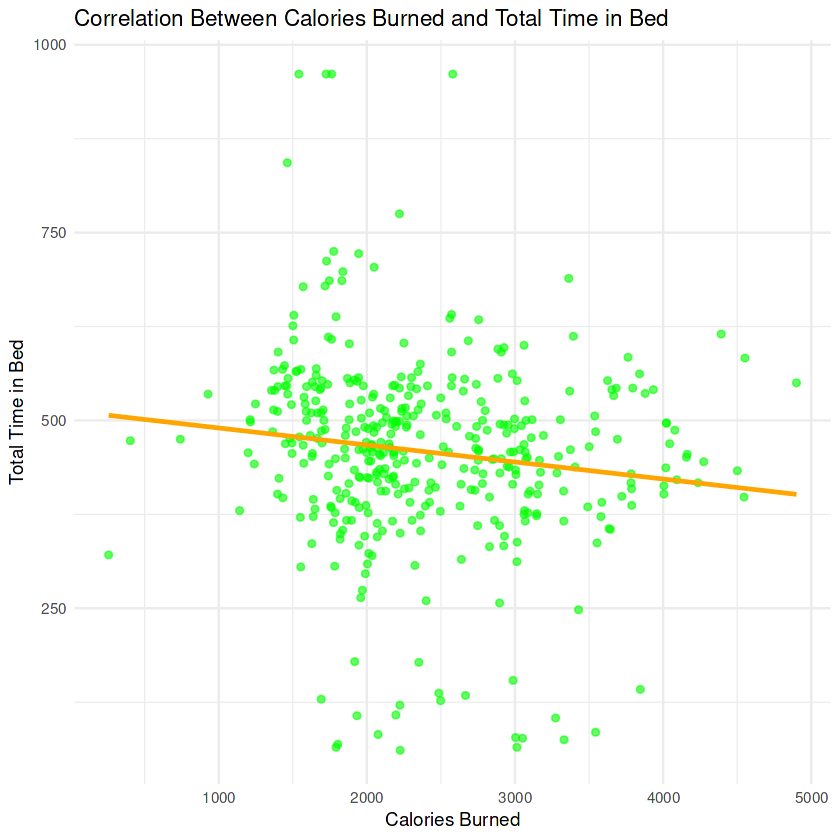

In [28]:
# Scatter plot: Calories vs. Total Time in Bed
ggplot(merged_data, aes(x = calories, y = totaltimeinbed)) +
  geom_point(alpha = 0.6, color = "green") +
  geom_smooth(method = "lm", color = "orange", se = FALSE) +
  labs(
    title = "Correlation Between Calories Burned and Total Time in Bed",
    x = "Calories Burned",
    y = "Total Time in Bed"
  ) +
  theme_minimal()

**Observation:** Similarly, calories burned shows a weak negative
correlation with time in bed. Higher calorie burn is associated with slightly less time in bed.

Notes: Both graphs show considerable variance/scatter in the data points
around the trend lines, suggesting these relationships aren't very
strong and other factors likely influence sleep patterns.

## 5.3 Meeting Recommended Level

I assessed the percentage of users that are achieving recommended level of daily activity and sleep.

-   Recommended sleep hours by [American Academy of Sleep Medicine and Sleep Research Society](https://pmc.ncbi.nlm.nih.gov/articles/PMC4434546/) is 7 hours/420 minutes

-   Recommended daily activity minutes by [World Health Organization](https://www.who.int/initiatives/behealthy/physical-activity) is 150 minutes of moderate activity

In [29]:
# Calculate Sleep Recommendation
sleep_achieved <- sleep_data_clean %>%
  mutate(sleep_achieved = ifelse(totalminutesasleep >= 420, 1, 0)) %>%
  summarise(percent_achieved_sleep = mean(sleep_achieved) * 100)

# Calculate Activity Recommendation
activity_achieved <- daily_activity_clean %>%
  mutate(active_minutes = veryactiveminutes + fairlyactiveminutes) %>%
  summarise(percent_achieved_activity = mean(active_minutes >= 150) * 100)

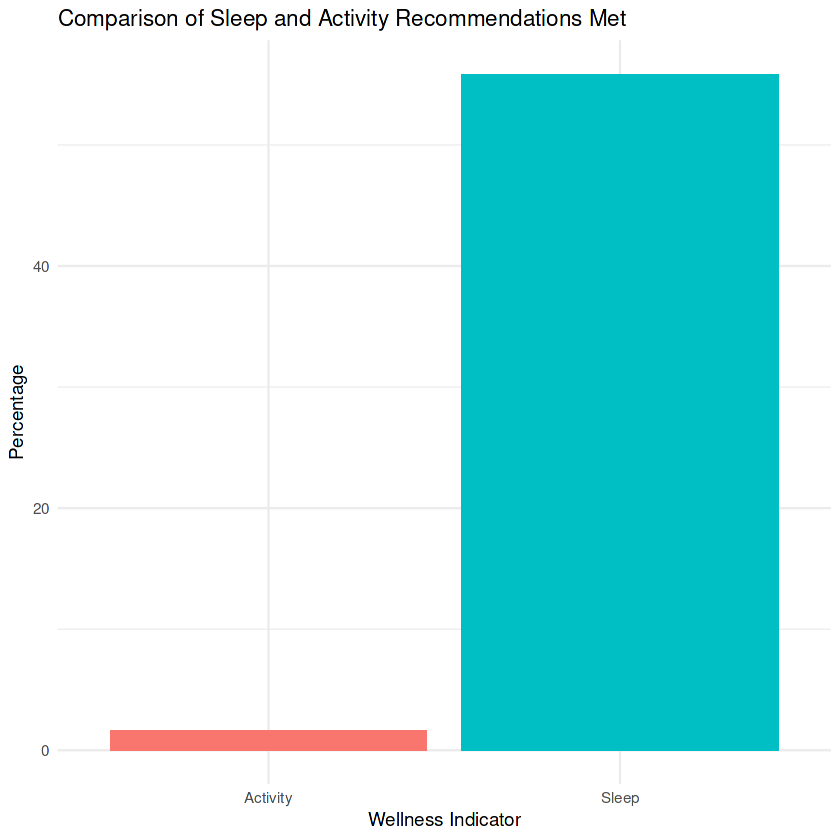

In [30]:
# Combined Sleep and Activity 

combined_data <- tibble(
  Category = c("Sleep", "Activity"),
  Percent = c(
    sleep_achieved$percent_achieved_sleep,
    activity_achieved$percent_achieved_activity
  )
)

# Combined chart
ggplot(combined_data, aes(x = Category, y = Percent, fill = Category)) +
  geom_bar(stat = "identity", show.legend = FALSE) +
  labs(title = "Comparison of Sleep and Activity Recommendations Met",
       x = "Wellness Indicator",
       y = "Percentage") +
  theme_minimal()

**Observations:**

-   55% of users meet the WHO-recommended 7+ hours of sleep per night.

-   Many users struggle to meet the WHO-recommended 150 minutes of moderate weekly activity.

Notes: This stark contrast indicates that users prioritize sleep habits
over physical activity, likely due to differing levels of effort
required or lack of awareness about the importance of activity.

# 6. Key Findings and Insights

## 6.1 Trends in Smart Device Usage

**Activity Patterns:**

-   Peak physical activity occurs 5-7 PM, with steady decline after 7
    PM.

-   Users maintain consistent activity levels between weekdays and
    weekends.

-   Majority of steps fall between 8,000-10,000 daily, aligning with
    common fitness goals.

-   Strong positive correlation between steps taken and calories burned.

-   Many users fall short of WHO-recommended 150 minutes weekly moderate
    activity.

**Sedentary Behavior:**

-   Clear negative correlation between steps taken and sedentary
    minutes.

-   High variability/scatter around the trend line, suggesting other
    factors influence sedentary time.

-   Some outliers with very low sedentary minutes (\<200) and very high
    steps (\>25,000).

-   Trend line suggests roughly 600 minute decrease in sedentary time
    from 0 to 30,000 steps.

**Sleep Habits:**

-   Slight negative correlation between physical activity and sleep
    duration.

-   Higher calorie burn associated with marginally reduced time in bed.

-   55% of users meet the WHO-recommended 7+ hours of sleep per night.

-   Sleep patterns show high variability, suggesting influence of
    multiple factors.

## 6.2 Relevance to Bellabeat Customers

The findings highlight key opportunities to engage and support Bellabeat
users in achieving their health and wellness goals:

-   Encouraging users to incorporate activity breaks to reduce sedentary
    time, particularly for those with desk jobs.

-   Promoting achievable daily step goals (e.g., 8,000–10,000 steps) to
    align with user behavior and fitness trends.

-   Offering guidance on balancing physical activity with adequate sleep
    to optimize overall well-being.

-   Educating users on lifestyle factors that influence sedentary
    behavior and sleep patterns.

## 6.3 Marketing Strategy Recommendations

-   **Personalized Notifications:** Integrate app reminders encouraging
    users to reach the 8,000–10,000 step range. These notifications
    could suggest short walks or engaging workouts to hit the goal.

-   **Sedentary Time Interventions:** Add features to the app to track
    sedentary minutes and suggest breaks for movement. Include
    motivational alerts to reduce prolonged inactivity.

-   **"Recovery Insights" Feature:** Develop an app module that tracks
    the balance between activity and sleep. Notify users when high
    activity levels negatively impact sleep quality, and recommend
    relaxation exercises or optimized bedtime routines.

-   **Gamification:** Implement rewards, badges, or streaks for meeting
    recommended activity levels (e.g., 150 minutes weekly) or
    maintaining consistent sleep patterns (e.g., 7+ hours per night).

-   **Content Campaigns:** Launch an educational series on topics such
    as balancing movement and rest, reducing sedentary time, and
    optimizing sleep. This could include blog posts, videos, and in-app
    tips tailored to user behavior.

These strategies can enhance user engagement, align with Bellabeat’s
mission to support wellness, and position the app as an essential tool
for achieving a balanced and healthy lifestyle.

# 7. Conclusion

The analysis reveals key trends in smart device usage that can guide
Bellabeat’s product development and marketing strategies. By leveraging
insights on activity patterns, sedentary behaviors, and sleep habits,
Bellabeat can create personalized, engaging features to enhance customer
experience and promote healthier lifestyles.

While 55% of users meet sleep goals, only 2% achieve the recommended
levels of physical activity. These insights present a dual opportunity
for Bellabeat to reinforce positive sleep habits and address the
substantial need for support in promoting physical activity.

By creating personalized, engaging features such as gamified challenges,
smart notifications, and educational content, Bellabeat can enhance the
customer experience and empower users to achieve balanced wellness.
These strategies align with Bellabeat’s mission of promoting healthier
lifestyles through data-driven solutions.

# 8. References

Kling, H. E., Yang, X., Messiah, S. E., Arheart, K. L., Brannan, D., & Caban-Martinez, A. J. (2016). Opportunities for increased physical activity in the workplace: The walking meeting (WaM) pilot study, Miami,2015. *Preventing Chronic Disease, 13*, 160111.
<https://doi.org/10.5888/pcd13.160111>

Physical activity. (n.d.). World Health Organization. Retrieved January
15, 2025, from
<https://www.who.int/initiatives/behealthy/physical-activity>

Watson, N. F., Badr, M. S., Belenky, G., Bliwise, D. L., Buxton, O. M., Buysse, D., Dinges, D. F., Gangwisch, J., Grandner, M. A., Kushida, C., Malhotra, R. K., Martin, J. L., Patel, S. R., Quan, S. F., & Tasali, E. (2015). Recommended amount of sleep for a healthy adult: A joint consensus statement of the American Academy of Sleep Medicine and Sleep Research Society. *Sleep, 38*(6), 843–844.